
# Gated Attention DeepSurv


In [2]:
!pip -q install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 12.1 MB/s eta 0:00:00


In [3]:
# =========================
# 1. Install / import packages
# =========================
import os
import math
import json
import time
import copy
import joblib
import random
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from lifelines.utils import concordance_index


In [5]:
# =========================
# 2. Mount Google Drive
# =========================
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [21]:
# =========================
# 3. Reproducibility
# =========================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda



## Set your dataset location

Update the path below after your teammate uploads the normalized METABRIC data to your shared Google Drive folder.

Examples:
- `/content/drive/MyDrive/ECEN766/METABRIC/metabric_normalized.npz`
- `/content/drive/MyDrive/ECEN766/METABRIC/`


In [7]:
# =========================
# 4. Data path configuration
# =========================



DATA_DIR = "/content/drive/MyDrive/ECEN766final/Processed"



# Set this to False if the parquet features are already normalized

STANDARDIZE_IN_NOTEBOOK = False



assert os.path.exists(DATA_DIR), f"Folder not found: {DATA_DIR}"
print("Found data folder:", DATA_DIR)
print("Files:", sorted(os.listdir(DATA_DIR)))


Found data folder: /content/drive/MyDrive/ECEN766final/Processed
Files: ['X_test.parquet', 'X_test2000.parquet', 'X_test500.parquet', 'X_train.parquet', 'X_train2000.parquet', 'X_train500.parquet', 'X_val.parquet', 'X_val2000.parquet', 'X_val500.parquet', 'scaler.pkl', 'scaler2000.pkl', 'scaler500.pkl', 'y_test.parquet', 'y_test2000.parquet', 'y_test500.parquet', 'y_train.parquet', 'y_train2000.parquet', 'y_train500.parquet', 'y_val.parquet', 'y_val2000.parquet', 'y_val500.parquet']


In [8]:
# =========================
# 5. Data loading helpers
# =========================


def _to_numpy(df_or_series):
    if hasattr(df_or_series, "to_numpy"):
        arr = df_or_series.to_numpy()
    else:
        arr = np.asarray(df_or_series)
    return arr

def _flatten_if_single_column(arr):
    arr = np.asarray(arr)
    if arr.ndim == 2 and arr.shape[1] == 1:
        arr = arr[:, 0]
    return arr

def _extract_time_event(y_df):
    """
    Flexible parser for y parquet files.

    Supported cases:
    1) Two columns with recognizable names, e.g.:
       - time/survival_time/os_time/months
       - event/status/e/os_event
    2) Exactly two columns -> assumes:
       first column = time, second column = event
    """
    if not isinstance(y_df, pd.DataFrame):
        y_df = pd.DataFrame(y_df)

    cols_lower = {c.lower(): c for c in y_df.columns}

    possible_time = [
        "time", "t", "duration", "survival_time", "overall_survival_time",
        "os_time", "months", "time_to_event"
    ]
    possible_event = [
        "event", "e", "status", "censor", "censored", "os_event",
        "overall_survival_event"
    ]

    time_col = None
    event_col = None

    for name in possible_time:
        if name in cols_lower:
            time_col = cols_lower[name]
            break

    for name in possible_event:
        if name in cols_lower:
            event_col = cols_lower[name]
            break

    if time_col is not None and event_col is not None:
        t = y_df[time_col].to_numpy(dtype=np.float32)
        e = y_df[event_col].to_numpy(dtype=np.float32)
        return t, e

    if y_df.shape[1] == 2:
        t = y_df.iloc[:, 0].to_numpy(dtype=np.float32)
        e = y_df.iloc[:, 1].to_numpy(dtype=np.float32)
        print("[Info] y parquet has 2 columns; assuming first=time, second=event.")
        return t, e

    raise ValueError(
        "Could not infer time/event columns from y parquet. "
        f"Found columns: {list(y_df.columns)}"
    )

def load_survival_data_from_parquet(data_dir: str):
    required = [
        "X_train.parquet", "X_val.parquet", "X_test.parquet",
        "y_train.parquet", "y_val.parquet", "y_test.parquet",
    ]
    for fname in required:
        fpath = os.path.join(data_dir, fname)
        if not os.path.exists(fpath):
            raise FileNotFoundError(f"Missing required file: {fpath}")

    X_train_df = pd.read_parquet(os.path.join(data_dir, "X_train.parquet"))
    X_val_df   = pd.read_parquet(os.path.join(data_dir, "X_val.parquet"))
    X_test_df  = pd.read_parquet(os.path.join(data_dir, "X_test.parquet"))

    y_train_df = pd.read_parquet(os.path.join(data_dir, "y_train.parquet"))
    y_val_df   = pd.read_parquet(os.path.join(data_dir, "y_val.parquet"))
    y_test_df  = pd.read_parquet(os.path.join(data_dir, "y_test.parquet"))

    t_train, e_train = _extract_time_event(y_train_df)
    t_val,   e_val   = _extract_time_event(y_val_df)
    t_test,  e_test  = _extract_time_event(y_test_df)

    train_data = {
        "x": _to_numpy(X_train_df).astype(np.float32),
        "t": t_train.astype(np.float32),
        "e": e_train.astype(np.float32),
    }
    val_data = {
        "x": _to_numpy(X_val_df).astype(np.float32),
        "t": t_val.astype(np.float32),
        "e": e_val.astype(np.float32),
    }
    test_data = {
        "x": _to_numpy(X_test_df).astype(np.float32),
        "t": t_test.astype(np.float32),
        "e": e_test.astype(np.float32),
    }

    feature_names = list(X_train_df.columns)

    return train_data, val_data, test_data, feature_names


In [9]:
# =========================
# 6. Load the parquet data
# =========================
train_data, val_data, test_data, feature_names = load_survival_data_from_parquet(DATA_DIR)

print("Train X shape:", train_data["x"].shape)
print("Val   X shape:", val_data["x"].shape)
print("Test  X shape:", test_data["x"].shape)

print("Train events:", int(np.sum(train_data["e"])))
print("Val events:", int(np.sum(val_data["e"])))
print("Test events:", int(np.sum(test_data["e"])))

print("Number of features:", len(feature_names))
print("First 10 feature names:", feature_names[:10])

print("\nSample y_train preview:")
display(pd.read_parquet(os.path.join(DATA_DIR, "y_train.parquet")).head())


Train X shape: (1386, 3000)
Val   X shape: (297, 3000)
Test  X shape: (297, 3000)
Train events: 799
Val events: 172
Test events: 171
Number of features: 3000
First 10 feature names: ['CTXN1', 'POFUT1', 'MRPL24', 'IDO1', 'CMIP', 'TUBGCP5', 'CLN8', 'SLC25A19', 'C5orf4', 'ZNF350']

Sample y_train preview:


Hugo_Symbol,time,event
MB-4849,45.333333,1
MB-0108,42.700000,1
MB-5157,18.233333,1
MB-0605,114.600000,0
MB-6122,260.200000,0


In [10]:
# Debug non-finite values in loaded x arrays
for split_name, data_dict in [("train", train_data), ("val", val_data), ("test", test_data)]:
    x = data_dict["x"]
    t = data_dict["t"]
    e = data_dict["e"]

    n_nan = np.isnan(x).sum()
    n_posinf = np.isposinf(x).sum()
    n_neginf = np.isneginf(x).sum()
    total_bad = n_nan + n_posinf + n_neginf

    print(f"{split_name}:")
    print(f"  x shape      = {x.shape}")
    print(f"  NaN count    = {n_nan}")
    print(f"  +inf count   = {n_posinf}")
    print(f"  -inf count   = {n_neginf}")
    print(f"  total bad    = {total_bad}")

    if total_bad > 0:
        bad_rows = np.where(~np.isfinite(x).all(axis=1))[0]
        bad_cols = np.where(~np.isfinite(x).all(axis=0))[0]

        print(f"  bad row indices (first 20): {bad_rows[:20]}")
        print(f"  bad col indices (first 20): {bad_cols[:20]}")

    print()

train:
  x shape      = (1386, 3000)
  NaN count    = 10
  +inf count   = 0
  -inf count   = 0
  total bad    = 10
  bad row indices (first 20): [ 196  245  440  445  574  679  680  681  734 1269]
  bad col indices (first 20): [0 1 2 3 4 5 6 7]

val:
  x shape      = (297, 3000)
  NaN count    = 1
  +inf count   = 0
  -inf count   = 0
  total bad    = 1
  bad row indices (first 20): [148]
  bad col indices (first 20): [4]

test:
  x shape      = (297, 3000)
  NaN count    = 2
  +inf count   = 0
  -inf count   = 0
  total bad    = 2
  bad row indices (first 20): [124 232]
  bad col indices (first 20): [1 7]



In [11]:
def impute_with_train_medians(train_data, val_data, test_data):
    x_train = train_data["x"].copy()
    x_val = val_data["x"].copy()
    x_test = test_data["x"].copy()

    print("Bad values before imputation:")
    print("  train:", np.isnan(x_train).sum())
    print("  val:  ", np.isnan(x_val).sum())
    print("  test: ", np.isnan(x_test).sum())

    # Compute medians from training set only
    train_medians = np.nanmedian(x_train, axis=0)

    # If a whole training column were NaN, fallback to 0.0
    train_medians = np.where(np.isfinite(train_medians), train_medians, 0.0)

    def fill_nan_with_reference_medians(x, medians):
        inds = np.where(np.isnan(x))
        if len(inds[0]) > 0:
            x[inds] = np.take(medians, inds[1])
        return x

    x_train = fill_nan_with_reference_medians(x_train, train_medians)
    x_val = fill_nan_with_reference_medians(x_val, train_medians)
    x_test = fill_nan_with_reference_medians(x_test, train_medians)

    train_data = train_data.copy()
    val_data = val_data.copy()
    test_data = test_data.copy()

    train_data["x"] = x_train
    val_data["x"] = x_val
    test_data["x"] = x_test

    print("\nBad values after imputation:")
    print("  train:", np.isnan(train_data["x"]).sum())
    print("  val:  ", np.isnan(val_data["x"]).sum())
    print("  test: ", np.isnan(test_data["x"]).sum())

    return train_data, val_data, test_data


train_data, val_data, test_data = impute_with_train_medians(train_data, val_data, test_data)

Bad values before imputation:
  train: 10
  val:   1
  test:  2

Bad values after imputation:
  train: 0
  val:   0
  test:  0


In [12]:

# =========================
# 7. Sanity checks
# =========================
def check_data_dict(data_dict, name="data"):
    x, t, e = data_dict["x"], data_dict["t"], data_dict["e"]
    assert len(x) == len(t) == len(e), f"{name}: mismatched lengths"
    assert np.isfinite(x).all(), f"{name}: x has non-finite values"
    assert np.isfinite(t).all(), f"{name}: t has non-finite values"
    assert np.isfinite(e).all(), f"{name}: e has non-finite values"
    assert set(np.unique(e)).issubset({0.0, 1.0}), f"{name}: e must contain only 0/1"
    assert np.all(t >= 0), f"{name}: survival times must be non-negative"

check_data_dict(train_data, "train")
check_data_dict(val_data, "val")
if test_data is not None:
    check_data_dict(test_data, "test")

print("All data checks passed.")


All data checks passed.


In [13]:

# =========================
# 8. Standardization helper
# =========================
class Standardizer:
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, x: torch.Tensor):
        self.mean = x.mean(dim=0, keepdim=True)
        self.std = x.std(dim=0, keepdim=True).clamp_min(1e-8)

    def transform(self, x: torch.Tensor) -> torch.Tensor:
        return (x - self.mean) / self.std


In [14]:

# =========================
# 9. Sorting helper
# =========================
def sort_by_time_desc(x: torch.Tensor, t: torch.Tensor, e: torch.Tensor):
    idx = torch.argsort(t, descending=True)
    return x[idx], t[idx], e[idx]


In [15]:
# ==========================================
# 10. Residual Gated Attention DeepSurv model
# ==========================================
class ResidualGatedAttentionDeepSurv(nn.Module):
    """
    Memory-efficient gated survival model for high-dimensional omics data.

    Improvements over the plain gated model:
    1) input LayerNorm for stability
    2) residual branch so the model does not over-suppress useful genes
    3) bottleneck gating network
    4) fusion block before survival head
    """
    def __init__(
        self,
        n_in: int,
        gate_hidden: int = 128,
        proj_hidden: int = 64,
        hidden_layers_sizes=(32,),
        dropout: float = 0.5,
        gate_activation: str = "sigmoid",
        gate_temperature: float = 1.0,
    ):
        super().__init__()

        self.n_in = n_in
        self.gate_activation = gate_activation
        self.gate_temperature = gate_temperature

        self.input_norm = nn.LayerNorm(n_in)

        # gate branch
        self.gate_net = nn.Sequential(
            nn.Linear(n_in, gate_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(gate_hidden, n_in),
        )

        # gated projection branch
        self.gated_proj = nn.Sequential(
            nn.Linear(n_in, proj_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # residual projection branch
        self.residual_proj = nn.Sequential(
            nn.Linear(n_in, proj_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # fusion block
        self.fusion = nn.Sequential(
            nn.Linear(2 * proj_hidden, proj_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # survival head
        layers = []
        in_dim = proj_hidden
        for h in hidden_layers_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.GELU())
            layers.append(nn.Dropout(dropout))
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.risk_head = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor, return_attention: bool = False):
        x_norm = self.input_norm(x)

        gate_logits = self.gate_net(x_norm) / self.gate_temperature

        if self.gate_activation == "softmax":
            gates = torch.softmax(gate_logits, dim=1)
        elif self.gate_activation == "sigmoid":
            gates = torch.sigmoid(gate_logits)
        else:
            raise ValueError("gate_activation must be 'sigmoid' or 'softmax'")

        x_gated = x_norm * gates

        z_gated = self.gated_proj(x_gated)
        z_resid = self.residual_proj(x_norm)

        z = self.fusion(torch.cat([z_gated, z_resid], dim=1))
        log_risk = self.risk_head(z).squeeze(-1)

        if return_attention:
            return log_risk, gates
        return log_risk


## Cox loss

This is a **baseline DeepSurv-style Cox partial likelihood loss** that assumes the batch is sorted by decreasing survival time.

Note: this is the simple repo-faithful baseline and does **not explicitly handle tied event times** with Breslow/Efron corrections.


In [16]:

# =========================
# 11. Cox partial likelihood loss
# =========================
def cox_ph_loss(log_hz: torch.Tensor, event: torch.Tensor) -> torch.Tensor:
    log_hz = log_hz.reshape(-1)
    event = event.reshape(-1).float()

    log_cum_risk = torch.logcumsumexp(log_hz, dim=0)
    losses = event * (log_cum_risk - log_hz)

    n_events = event.sum().clamp_min(1.0)
    return losses.sum() / n_events


In [17]:

# =========================
# 12. Utility: c-index evaluation
# =========================
def evaluate_cindex(model, data, scaler=None, device="cpu"):
    model.eval()

    x = torch.tensor(data["x"], dtype=torch.float32, device=device)
    t = torch.tensor(data["t"], dtype=torch.float32, device=device)
    e = torch.tensor(data["e"], dtype=torch.float32, device=device)

    if scaler is not None:
        x = scaler.transform(x)

    with torch.no_grad():
        pred = model(x).detach().cpu().numpy()

    return concordance_index(
        t.detach().cpu().numpy(),
        -pred,  # higher risk should correspond to shorter survival
        e.detach().cpu().numpy()
    )


In [18]:
# =========================
# 13. Training loop
# =========================
def train_deepsurv(
    model,
    train_data,
    valid_data,
    n_epochs=150,
    learning_rate=3e-4,
    weight_decay=1e-3,
    standardize=True,
    device="cpu",
    verbose_every=25,
    gradient_clip=1.0,
    early_stopping_patience=20,
    gate_sparsity_lambda=0.0,
):
    model.to(device)

    x_train = torch.tensor(train_data["x"], dtype=torch.float32, device=device)
    t_train = torch.tensor(train_data["t"], dtype=torch.float32, device=device)
    e_train = torch.tensor(train_data["e"], dtype=torch.float32, device=device)

    scaler = None
    if standardize:
        scaler = Standardizer()
        scaler.fit(x_train)
        x_train = scaler.transform(x_train)

    x_train, t_train, e_train = sort_by_time_desc(x_train, t_train, e_train)

    x_val = t_val = e_val = None
    if valid_data is not None:
        x_val = torch.tensor(valid_data["x"], dtype=torch.float32, device=device)
        t_val = torch.tensor(valid_data["t"], dtype=torch.float32, device=device)
        e_val = torch.tensor(valid_data["e"], dtype=torch.float32, device=device)

        if scaler is not None:
            x_val = scaler.transform(x_val)

        x_val, t_val, e_val = sort_by_time_desc(x_val, t_val, e_val)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=5,
        min_lr=1e-5,
    )

    history = []

    best_state = None
    best_epoch = None
    best_val_ci = -float("inf")
    best_val_loss = float("inf")
    patience_counter = 0

    total_start_time = time.time()

    for epoch in range(1, n_epochs + 1):
        epoch_start_time = time.time()

        model.train()
        optimizer.zero_grad()

        log_hz_train, gates_train = model(x_train, return_attention=True)
        train_loss = cox_ph_loss(log_hz_train, e_train)

        if gate_sparsity_lambda > 0:
            gate_penalty = gates_train.mean()
            total_loss = train_loss + gate_sparsity_lambda * gate_penalty
        else:
            gate_penalty = torch.tensor(0.0, device=device)
            total_loss = train_loss

        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=gradient_clip)
        optimizer.step()

        model.eval()
        with torch.no_grad():
            train_pred = model(x_train).detach().cpu().numpy()
            train_ci = concordance_index(
                t_train.detach().cpu().numpy(),
                -train_pred,
                e_train.detach().cpu().numpy()
            )

        row = {
            "epoch": epoch,
            "train_loss": float(train_loss.item()),
            "total_loss": float(total_loss.item()),
            "gate_penalty": float(gate_penalty.item()),
            "train_cindex": float(train_ci),
            "lr": float(optimizer.param_groups[0]["lr"]),
        }

        if x_val is not None:
            with torch.no_grad():
                val_pred_t = model(x_val)
                val_loss = cox_ph_loss(val_pred_t, e_val)
                val_pred = val_pred_t.detach().cpu().numpy()
                val_ci = concordance_index(
                    t_val.detach().cpu().numpy(),
                    -val_pred,
                    e_val.detach().cpu().numpy()
                )

            row["val_loss"] = float(val_loss.item())
            row["val_cindex"] = float(val_ci)

            scheduler.step(val_ci)

            # early stop on validation C-index, tie-break on validation loss
            improved = (
                (val_ci > best_val_ci + 1e-6) or
                (abs(val_ci - best_val_ci) <= 1e-6 and val_loss.item() < best_val_loss)
            )

            if improved:
                best_val_ci = float(val_ci)
                best_val_loss = float(val_loss.item())
                best_state = copy.deepcopy(model.state_dict())
                best_epoch = epoch
                patience_counter = 0
            else:
                patience_counter += 1

        epoch_time_sec = time.time() - epoch_start_time
        elapsed_time_min = (time.time() - total_start_time) / 60.0

        row["epoch_time_sec"] = float(epoch_time_sec)
        row["elapsed_time_min"] = float(elapsed_time_min)
        history.append(row)

        if (epoch == 1) or (epoch % verbose_every == 0) or (epoch == n_epochs):
            msg = (
                f"Epoch {epoch:03d} | "
                f"train_loss={row['train_loss']:.4f} | "
                f"train_c={row['train_cindex']:.4f}"
            )
            if "val_loss" in row:
                msg += (
                    f" | val_loss={row['val_loss']:.4f}"
                    f" | val_c={row['val_cindex']:.4f}"
                )
            msg += (
                f" | lr={row['lr']:.6f}"
                f" | epoch_time={row['epoch_time_sec']:.1f}s"
                f" | elapsed={row['elapsed_time_min']:.1f}m"
            )
            if best_epoch is not None:
                msg += f" | best_epoch={best_epoch}"
            print(msg)

        if x_val is not None and patience_counter >= early_stopping_patience:
            print(f"Early stopping at epoch {epoch:03d}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Restored best model from epoch {best_epoch} with val_c={best_val_ci:.4f}, val_loss={best_val_loss:.4f}")

    history_df = pd.DataFrame(history)
    return history_df, scaler, best_epoch, best_val_loss, best_val_ci

In [19]:
# =========================
# 14. General training settings
# =========================
N_FEATURES = train_data["x"].shape[1]

N_EPOCHS = 200
EARLY_STOPPING_PATIENCE = 20
GRADIENT_CLIP = 1.0
STANDARDIZE = STANDARDIZE_IN_NOTEBOOK

print("Number of input features:", N_FEATURES)
print("Max epochs:", N_EPOCHS)
print("Early stopping patience:", EARLY_STOPPING_PATIENCE)
print("Gradient clip:", GRADIENT_CLIP)

Number of input features: 3000
Max epochs: 200
Early stopping patience: 20
Gradient clip: 1.0


In [60]:
# ===========================================================================
# 15. Hyperparameter tuning for Residual Gated Attention DeepSurv
# ===========================================================================

param_grid = {
    "gate_hidden": [128, 256],
    "proj_hidden": [64],
    "hidden_layers_sizes": [(32,), (64,)],
    "dropout": [0.5, 0.6],
    "learning_rate": [3e-4, 1e-4],
    "weight_decay": [1e-3, 3e-3],
    "gate_activation": ["sigmoid"],
    "gate_temperature": [1.0],
    "gate_sparsity_lambda": [0.0, 1e-4],
}

all_param_sets = [
    dict(zip(param_grid.keys(), values))
    for values in itertools.product(*param_grid.values())
]

# optional: cut this down if too many trials
# all_param_sets = all_param_sets[:40]

seeds = [42, 52, 62]

print(f"Total configs: {len(all_param_sets)}")
print(f"Seeds per config: {len(seeds)}")
print(f"Total runs: {len(all_param_sets) * len(seeds)}")

results = []
best_params = None
best_mean_val_ci = -float("inf")

for i, params in enumerate(all_param_sets, start=1):
    print(f"\n===== Config {i}/{len(all_param_sets)} =====")
    print(params)

    seed_rows = []

    for seed in seeds:
        set_seed(seed)

        model = ResidualGatedAttentionDeepSurv(
            n_in=N_FEATURES,
            gate_hidden=params["gate_hidden"],
            proj_hidden=params["proj_hidden"],
            hidden_layers_sizes=params["hidden_layers_sizes"],
            dropout=params["dropout"],
            gate_activation=params["gate_activation"],
            gate_temperature=params["gate_temperature"],
        )

        history_df, scaler, best_epoch, best_val_loss, best_val_ci = train_deepsurv(
            model=model,
            train_data=train_data,
            valid_data=val_data,
            n_epochs=N_EPOCHS,
            learning_rate=params["learning_rate"],
            weight_decay=params["weight_decay"],
            standardize=STANDARDIZE,
            device=DEVICE,
            verbose_every=9999,
            gradient_clip=GRADIENT_CLIP,
            early_stopping_patience=EARLY_STOPPING_PATIENCE,
            gate_sparsity_lambda=params["gate_sparsity_lambda"],
        )

        train_ci = evaluate_cindex(model, train_data, scaler=scaler, device=DEVICE)
        val_ci = evaluate_cindex(model, val_data, scaler=scaler, device=DEVICE)

        seed_rows.append({
            "seed": seed,
            "best_epoch": best_epoch,
            "best_val_loss": best_val_loss,
            "train_cindex": train_ci,
            "val_cindex": val_ci,
        })

    mean_train_ci = float(np.mean([r["train_cindex"] for r in seed_rows]))
    mean_val_ci = float(np.mean([r["val_cindex"] for r in seed_rows]))
    std_val_ci = float(np.std([r["val_cindex"] for r in seed_rows]))
    mean_best_epoch = float(np.mean([r["best_epoch"] for r in seed_rows]))
    mean_best_val_loss = float(np.mean([r["best_val_loss"] for r in seed_rows]))

    row = params.copy()
    row["mean_train_cindex"] = mean_train_ci
    row["mean_val_cindex"] = mean_val_ci
    row["std_val_cindex"] = std_val_ci
    row["mean_best_epoch"] = mean_best_epoch
    row["mean_best_val_loss"] = mean_best_val_loss
    results.append(row)

    if mean_val_ci > best_mean_val_ci:
        best_mean_val_ci = mean_val_ci
        best_params = params.copy()

results_df = pd.DataFrame(results).sort_values(
    ["mean_val_cindex", "std_val_cindex"],
    ascending=[False, True]
).reset_index(drop=True)

print("\nTop tuning results:")
display(results_df.head(10))

print("\nBest params:")
print(best_params)
print(f"Best mean validation C-index: {best_mean_val_ci:.4f}")

Total configs: 64
Seeds per config: 3
Total runs: 192

===== Config 1/64 =====
{'gate_hidden': 128, 'proj_hidden': 64, 'hidden_layers_sizes': (32,), 'dropout': 0.5, 'learning_rate': 0.0003, 'weight_decay': 0.001, 'gate_activation': 'sigmoid', 'gate_temperature': 1.0, 'gate_sparsity_lambda': 0.0}
Epoch 001 | train_loss=6.5332 | train_c=0.5934 | val_loss=4.9574 | val_c=0.5470 | lr=0.000300 | epoch_time=0.0s | elapsed=0.0m | best_epoch=1
Early stopping at epoch 064
Restored best model from epoch 44 with val_c=0.6366, val_loss=4.8834
Epoch 001 | train_loss=6.5313 | train_c=0.5863 | val_loss=4.9584 | val_c=0.5167 | lr=0.000300 | epoch_time=0.0s | elapsed=0.0m | best_epoch=1
Early stopping at epoch 063
Restored best model from epoch 43 with val_c=0.6429, val_loss=4.8809
Epoch 001 | train_loss=6.5319 | train_c=0.6004 | val_loss=4.9551 | val_c=0.5608 | lr=0.000300 | epoch_time=0.0s | elapsed=0.0m | best_epoch=1
Early stopping at epoch 066
Restored best model from epoch 46 with val_c=0.6356, va

,gate_hidden,proj_hidden,hidden_layers_sizes,dropout,learning_rate,weight_decay,gate_activation,gate_temperature,gate_sparsity_lambda,mean_train_cindex,mean_val_cindex,std_val_cindex,mean_best_epoch,mean_best_val_loss
0,128,64,"(64,)",0.6,0.0003,0.003,sigmoid,1.0,0.0000,0.860466,0.651887,0.007225,53.333333,4.860760
1,128,64,"(64,)",0.6,0.0003,0.003,sigmoid,1.0,0.0001,0.860464,0.651887,0.007225,53.333333,4.860757
2,128,64,"(64,)",0.6,0.0003,0.001,sigmoid,1.0,0.0000,0.860474,0.651876,0.007213,53.333333,4.860763
3,128,64,"(64,)",0.6,0.0003,0.001,sigmoid,1.0,0.0001,0.860472,0.651876,0.007213,53.333333,4.860760
4,128,64,"(64,)",0.5,0.0003,0.001,sigmoid,1.0,0.0000,0.855254,0.649361,0.006002,43.333333,4.872427
5,128,64,"(64,)",0.5,0.0003,0.001,sigmoid,1.0,0.0001,0.855254,0.649351,0.006017,43.333333,4.872423
6,128,64,"(64,)",0.5,0.0003,0.003,sigmoid,1.0,0.0000,0.855251,0.649351,0.006017,43.333333,4.872424
7,128,64,"(64,)",0.5,0.0003,0.003,sigmoid,1.0,0.0001,0.855250,0.649351,0.006017,43.333333,4.872420
8,256,64,"(32,)",0.5,0.0003,0.001,sigmoid,1.0,0.0000,0.862818,0.649230,0.001720,46.000000,4.870475
9,256,64,"(32,)",0.5,0.0003,0.003,sigmoid,1.0,0.0000,0.862814,0.649219,0.001712,46.000000,4.870472



Best params:
{'gate_hidden': 128, 'proj_hidden': 64, 'hidden_layers_sizes': (64,), 'dropout': 0.6, 'learning_rate': 0.0003, 'weight_decay': 0.003, 'gate_activation': 'sigmoid', 'gate_temperature': 1.0, 'gate_sparsity_lambda': 0.0}
Best mean validation C-index: 0.6519


In [61]:
# ==================================================================
# 16. Train final selected Residual Gated Attention DeepSurv
# ==================================================================
GATE_HIDDEN = best_params["gate_hidden"]
PROJ_HIDDEN = best_params["proj_hidden"]
HIDDEN_LAYERS = best_params["hidden_layers_sizes"]
DROPOUT = best_params["dropout"]
LEARNING_RATE = best_params["learning_rate"]
WEIGHT_DECAY = best_params["weight_decay"]
GATE_ACTIVATION = best_params["gate_activation"]
GATE_TEMPERATURE = best_params["gate_temperature"]
GATE_SPARSITY_LAMBDA = best_params["gate_sparsity_lambda"]

final_seeds = [42, 52, 62]

best_final_val_ci = -float("inf")
best_final_state = None
best_final_scaler = None
best_final_history = None
best_epoch = None
best_val_loss = None
best_seed = None

for seed in final_seeds:
    print(f"\n===== Final retrain with seed {seed} =====")
    set_seed(seed)

    candidate_model = ResidualGatedAttentionDeepSurv(
        n_in=N_FEATURES,
        gate_hidden=GATE_HIDDEN,
        proj_hidden=PROJ_HIDDEN,
        hidden_layers_sizes=HIDDEN_LAYERS,
        dropout=DROPOUT,
        gate_activation=GATE_ACTIVATION,
        gate_temperature=GATE_TEMPERATURE,
    )

    candidate_history, candidate_scaler, candidate_best_epoch, candidate_best_val_loss, candidate_best_val_ci = train_deepsurv(
        model=candidate_model,
        train_data=train_data,
        valid_data=val_data,
        n_epochs=N_EPOCHS,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        standardize=STANDARDIZE,
        device=DEVICE,
        verbose_every=10,
        gradient_clip=GRADIENT_CLIP,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        gate_sparsity_lambda=GATE_SPARSITY_LAMBDA,
    )

    print(f"Seed {seed} | best val C-index = {candidate_best_val_ci:.4f}")

    if candidate_best_val_ci > best_final_val_ci:
        best_final_val_ci = candidate_best_val_ci
        model = candidate_model
        scaler = candidate_scaler
        history_df = candidate_history.copy()
        best_epoch = candidate_best_epoch
        best_val_loss = candidate_best_val_loss
        best_seed = seed

print("\nFinal selected model finished.")
print("Best params:", best_params)
print("Best seed:", best_seed)
print(f"Best restored epoch: {best_epoch}")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Best validation C-index: {best_final_val_ci:.4f}")
display(history_df.tail())


===== Final retrain with seed 42 =====
Epoch 001 | train_loss=6.5332 | train_c=0.5795 | val_loss=4.9558 | val_c=0.5667 | lr=0.000300 | epoch_time=0.0s | elapsed=0.0m | best_epoch=1
Epoch 010 | train_loss=6.4988 | train_c=0.6416 | val_loss=4.9396 | val_c=0.5852 | lr=0.000300 | epoch_time=0.0s | elapsed=0.0m | best_epoch=10
Epoch 020 | train_loss=6.4435 | train_c=0.6790 | val_loss=4.9182 | val_c=0.6036 | lr=0.000300 | epoch_time=0.0s | elapsed=0.0m | best_epoch=20
Epoch 030 | train_loss=6.3741 | train_c=0.7299 | val_loss=4.8881 | val_c=0.6302 | lr=0.000300 | epoch_time=0.0s | elapsed=0.0m | best_epoch=30
Epoch 040 | train_loss=6.2240 | train_c=0.7881 | val_loss=4.8580 | val_c=0.6456 | lr=0.000300 | epoch_time=0.0s | elapsed=0.0m | best_epoch=40
Epoch 050 | train_loss=6.0501 | train_c=0.8456 | val_loss=4.8584 | val_c=0.6514 | lr=0.000300 | epoch_time=0.0s | elapsed=0.0m | best_epoch=50
Epoch 060 | train_loss=5.8185 | train_c=0.8912 | val_loss=4.8992 | val_c=0.6356 | lr=0.000150 | epoch_t

,epoch,train_loss,total_loss,gate_penalty,train_cindex,lr,val_loss,val_cindex,epoch_time_sec,elapsed_time_min
71,72,5.726593,5.726593,0.0,0.911690,0.000075,4.874640,0.647725,0.028211,0.034788
72,73,5.701999,5.701999,0.0,0.912299,0.000075,4.874848,0.647660,0.028460,0.035262
73,74,5.737030,5.737030,0.0,0.912998,0.000075,4.874987,0.647363,0.028128,0.035731
74,75,5.718130,5.718130,0.0,0.913318,0.000037,4.875281,0.647692,0.028183,0.036201
75,76,5.693939,5.693939,0.0,0.913705,0.000037,4.875812,0.647264,0.027876,0.036665


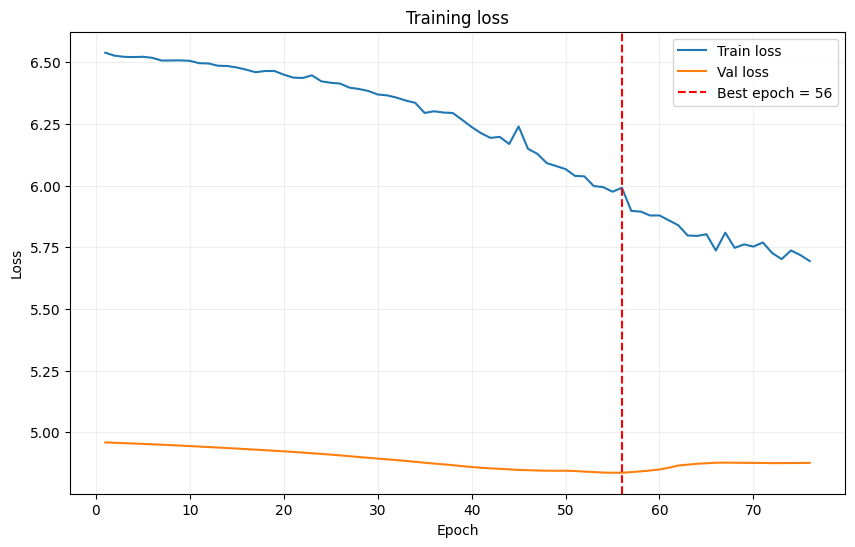

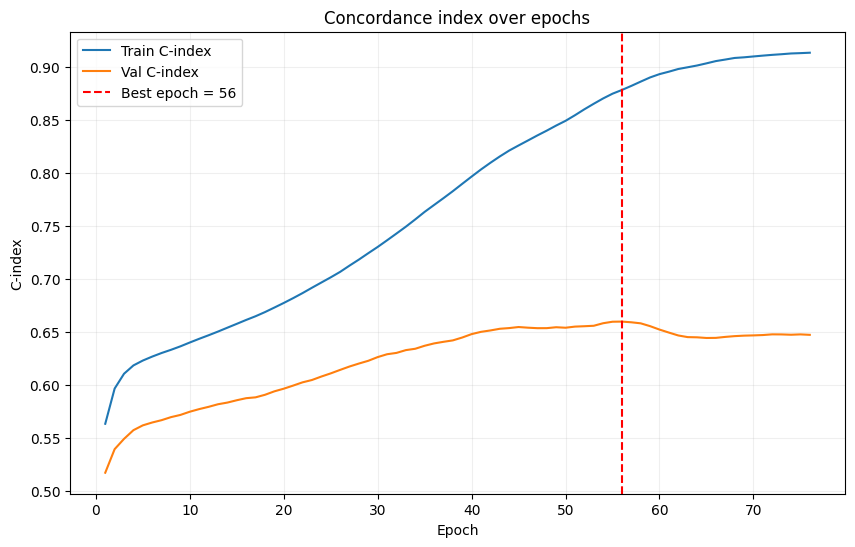

Best restored epoch: 56
Best validation loss: 4.8358


,epoch,train_loss,total_loss,gate_penalty,train_cindex,lr,val_loss,val_cindex,epoch_time_sec,elapsed_time_min
71,72,5.726593,5.726593,0.0,0.911690,0.000075,4.874640,0.647725,0.028211,0.034788
72,73,5.701999,5.701999,0.0,0.912299,0.000075,4.874848,0.647660,0.028460,0.035262
73,74,5.737030,5.737030,0.0,0.912998,0.000075,4.874987,0.647363,0.028128,0.035731
74,75,5.718130,5.718130,0.0,0.913318,0.000037,4.875281,0.647692,0.028183,0.036201
75,76,5.693939,5.693939,0.0,0.913705,0.000037,4.875812,0.647264,0.027876,0.036665


In [62]:

# =========================
# 17. Plot training history
# =========================
plt.figure(figsize=(10, 6))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
if "val_loss" in history_df.columns:
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Val loss")
if best_epoch is not None:
    plt.axvline(best_epoch, color="red", linestyle="--", label=f"Best epoch = {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.legend()
plt.grid(True, alpha=0.2)
plt.savefig("/content/drive/MyDrive/ECEN766final/ResidualGatedAttentionDeepSurv/plot_residual_gated_TrainingLoss.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(history_df["epoch"], history_df["train_cindex"], label="Train C-index")
if "val_cindex" in history_df.columns:
    plt.plot(history_df["epoch"], history_df["val_cindex"], label="Val C-index")
if best_epoch is not None:
    plt.axvline(best_epoch, color="red", linestyle="--", label=f"Best epoch = {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("C-index")
plt.title("Concordance index over epochs")
plt.legend()
plt.grid(True, alpha=0.2)
plt.savefig("/content/drive/MyDrive/ECEN766final/ResidualGatedAttentionDeepSurv/plot_residual_gated_Cindex_over_epochs.png", dpi=300)
plt.show()

print(f"Best restored epoch: {best_epoch}")
print(f"Best validation loss: {best_val_loss:.4f}")
history_df.tail()

In [63]:

# =========================
# 18. Final evaluation
# =========================
train_ci = evaluate_cindex(model, train_data, scaler=scaler, device=DEVICE)
val_ci = evaluate_cindex(model, val_data, scaler=scaler, device=DEVICE)

print(f"Final Train C-index: {train_ci:.4f}")
print(f"Final Val   C-index: {val_ci:.4f}")

if test_data is not None:
    test_ci = evaluate_cindex(model, test_data, scaler=scaler, device=DEVICE)
    print(f"Final Test  C-index: {test_ci:.4f}")


Final Train C-index: 0.8785
Final Val   C-index: 0.6598
Final Test  C-index: 0.6623


In [64]:
# =========================
# 19. Save model, scaler, history, feature names, and gate summaries
# =========================

OUTPUT_DIR = "/content/drive/MyDrive/ECEN766final/ResidualGatedAttentionDeepSurv"
os.makedirs(OUTPUT_DIR, exist_ok=True)

model_path = os.path.join(OUTPUT_DIR, "residual_gated_attention_deepsurv_model.pt")
history_path = os.path.join(OUTPUT_DIR, "residual_gated_attention_deepsurv_training_history.csv")
feature_names_path = os.path.join(OUTPUT_DIR, "residual_gated_attention_deepsurv_feature_names.txt")
scaler_path = os.path.join(OUTPUT_DIR, "residual_gated_attention_deepsurv_scaler.npz")
config_path = os.path.join(OUTPUT_DIR, "residual_gated_attention_deepsurv_config.json")

gate_summary_path = os.path.join(OUTPUT_DIR, "residual_gate_summary.csv")
top_genes_path = os.path.join(OUTPUT_DIR, "residual_top_gated_genes.csv")


# Save model weights
torch.save(model.state_dict(), model_path)


# Save history
history_df.to_csv(history_path, index=False)


# Save feature names
with open(feature_names_path, "w") as f:
    for name in feature_names:
        f.write(f"{name}\n")


# Save scaler
if scaler is not None:
    np.savez(
        scaler_path,
        mean=scaler.mean.detach().cpu().numpy(),
        std=scaler.std.detach().cpu().numpy(),
    )


# Save config
config_to_save = {
    "model_class": model.__class__.__name__,
    "n_features": N_FEATURES,
    "gate_hidden": GATE_HIDDEN,
    "proj_hidden": PROJ_HIDDEN,
    "hidden_layers_sizes": list(HIDDEN_LAYERS),
    "dropout": DROPOUT,
    "gate_activation": GATE_ACTIVATION,
    "gate_temperature": GATE_TEMPERATURE,
    "gate_sparsity_lambda": GATE_SPARSITY_LAMBDA,
    "standardize": STANDARDIZE,
    "n_epochs": N_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "gradient_clip": GRADIENT_CLIP,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
}
with open(config_path, "w") as f:
    json.dump(config_to_save, f, indent=2)


# Compute and save gate summaries
model.eval()

x_all = torch.tensor(train_data["x"], dtype=torch.float32, device=DEVICE)

if scaler is not None:
    x_all = scaler.transform(x_all)

with torch.no_grad():
    log_risk, gates = model(x_all, return_attention=True)

# gates shape: [B, P]
gates_np = gates.detach().cpu().numpy()

# Mean gate score across all patients
mean_gate_scores = gates_np.mean(axis=0)   # [P]
std_gate_scores = gates_np.std(axis=0)     # [P]

gate_summary_df = pd.DataFrame({
    "gene": feature_names,
    "mean_gate_score": mean_gate_scores,
    "std_gate_score": std_gate_scores,
}).sort_values("mean_gate_score", ascending=False)

top_genes_df = gate_summary_df.head(20).copy()
top_genes_df.insert(0, "rank", range(1, len(top_genes_df) + 1))

gate_summary_df.to_csv(gate_summary_path, index=False)
top_genes_df.to_csv(top_genes_path, index=False)


# Print summary
print("Saved model to:", model_path)
print("Saved history to:", history_path)
print("Saved feature names to:", feature_names_path)
print("Saved config to:", config_path)
print("Saved gate summary to:", gate_summary_path)
print("Saved top gated genes to:", top_genes_path)

if scaler is not None:
    print("Saved scaler to:", scaler_path)
else:
    print("No notebook scaler saved because STANDARDIZE=False.")

Saved model to: /content/drive/MyDrive/ECEN766final/GatedAttentionDeepSurv/gated_attention_deepsurv_model.pt
Saved history to: /content/drive/MyDrive/ECEN766final/GatedAttentionDeepSurv/gated_attention_deepsurv_training_history.csv
Saved feature names to: /content/drive/MyDrive/ECEN766final/GatedAttentionDeepSurv/gated_attention_deepsurv_feature_names.txt
Saved config to: /content/drive/MyDrive/ECEN766final/GatedAttentionDeepSurv/gated_attention_deepsurv_config.json
Saved gate summary to: /content/drive/MyDrive/ECEN766final/GatedAttentionDeepSurv/gate_summary.csv
Saved top gated genes to: /content/drive/MyDrive/ECEN766final/GatedAttentionDeepSurv/top_gated_genes.csv
No notebook scaler saved because STANDARDIZE=False.


In [22]:
# ===========================================================================
# Hyperparameter tuning for Residual Gated Attention DeepSurv (With Stronger Regularization)
# ===========================================================================
param_grid = {
    "gate_hidden": [64, 128],
    "proj_hidden": [32, 64],
    "hidden_layers_sizes": [(32,), (64,)],
    "dropout": [0.6, 0.7],
    "learning_rate": [1e-4, 3e-4],
    "weight_decay": [3e-3, 1e-2],
    "gate_activation": ["sigmoid"],
    "gate_temperature": [1.0],
    "gate_sparsity_lambda": [1e-4, 5e-4, 1e-3],
}


all_param_sets = [
    dict(zip(param_grid.keys(), values))
    for values in itertools.product(*param_grid.values())
]

# optional: cut this down if too many trials
# all_param_sets = all_param_sets[:40]

seeds = [42, 52, 62]

print(f"Total configs: {len(all_param_sets)}")
print(f"Seeds per config: {len(seeds)}")
print(f"Total runs: {len(all_param_sets) * len(seeds)}")

results = []
best_params = None
best_mean_val_ci = -float("inf")
best_std_val_ci = float("inf")

for i, params in enumerate(all_param_sets, start=1):
    print(f"\n===== Config {i}/{len(all_param_sets)} =====")
    print(params)

    seed_rows = []

    for seed in seeds:
        set_seed(seed)

        model = ResidualGatedAttentionDeepSurv(
            n_in=N_FEATURES,
            gate_hidden=params["gate_hidden"],
            proj_hidden=params["proj_hidden"],
            hidden_layers_sizes=params["hidden_layers_sizes"],
            dropout=params["dropout"],
            gate_activation=params["gate_activation"],
            gate_temperature=params["gate_temperature"],
        )

        history_df, scaler, best_epoch, best_val_loss, best_val_ci = train_deepsurv(
            model=model,
            train_data=train_data,
            valid_data=val_data,
            n_epochs=N_EPOCHS,
            learning_rate=params["learning_rate"],
            weight_decay=params["weight_decay"],
            standardize=STANDARDIZE,
            device=DEVICE,
            verbose_every=9999,
            gradient_clip=GRADIENT_CLIP,
            early_stopping_patience=EARLY_STOPPING_PATIENCE,
            gate_sparsity_lambda=params["gate_sparsity_lambda"],
        )

        train_ci = evaluate_cindex(model, train_data, scaler=scaler, device=DEVICE)
        val_ci = evaluate_cindex(model, val_data, scaler=scaler, device=DEVICE)

        seed_rows.append({
            "seed": seed,
            "best_epoch": best_epoch,
            "best_val_loss": best_val_loss,
            "train_cindex": train_ci,
            "val_cindex": val_ci,
        })

    mean_train_ci = float(np.mean([r["train_cindex"] for r in seed_rows]))
    mean_val_ci = float(np.mean([r["val_cindex"] for r in seed_rows]))
    std_val_ci = float(np.std([r["val_cindex"] for r in seed_rows]))
    mean_best_epoch = float(np.mean([r["best_epoch"] for r in seed_rows]))
    mean_best_val_loss = float(np.mean([r["best_val_loss"] for r in seed_rows]))

    row = params.copy()
    row["mean_train_cindex"] = mean_train_ci
    row["mean_val_cindex"] = mean_val_ci
    row["std_val_cindex"] = std_val_ci
    row["mean_best_epoch"] = mean_best_epoch
    row["mean_best_val_loss"] = mean_best_val_loss
    results.append(row)

    if (
        (mean_val_ci > best_mean_val_ci + 1e-6) or
        (
            abs(mean_val_ci - best_mean_val_ci) <= 1e-6
            and std_val_ci < best_std_val_ci
        )
    ):
        best_mean_val_ci = mean_val_ci
        best_std_val_ci = std_val_ci
        best_params = params.copy()

results_df = pd.DataFrame(results).sort_values(
    ["mean_val_cindex", "std_val_cindex"],
    ascending=[False, True]
).reset_index(drop=True)

print("\nTop tuning results:")
display(results_df.head(10))

print("\nBest params:")
print(best_params)
print(f"Best mean validation C-index: {best_mean_val_ci:.4f}")
print(f"Best validation C-index std: {best_std_val_ci:.4f}")

Total configs: 192
Seeds per config: 3
Total runs: 576

===== Config 1/192 =====
{'gate_hidden': 64, 'proj_hidden': 32, 'hidden_layers_sizes': (32,), 'dropout': 0.6, 'learning_rate': 0.0001, 'weight_decay': 0.003, 'gate_activation': 'sigmoid', 'gate_temperature': 1.0, 'gate_sparsity_lambda': 0.0001}
Epoch 001 | train_loss=6.5315 | train_c=0.5256 | val_loss=4.9599 | val_c=0.4598 | lr=0.000100 | epoch_time=1.2s | elapsed=0.0m | best_epoch=1
Early stopping at epoch 171
Restored best model from epoch 151 with val_c=0.6416, val_loss=4.8846
Epoch 001 | train_loss=6.5325 | train_c=0.5138 | val_loss=4.9588 | val_c=0.4664 | lr=0.000100 | epoch_time=0.0s | elapsed=0.0m | best_epoch=1
Early stopping at epoch 161
Restored best model from epoch 141 with val_c=0.6334, val_loss=4.8758
Epoch 001 | train_loss=6.5323 | train_c=0.5234 | val_loss=4.9576 | val_c=0.5447 | lr=0.000100 | epoch_time=0.0s | elapsed=0.0m | best_epoch=1
Epoch 200 | train_loss=5.9833 | train_c=0.8860 | val_loss=4.8605 | val_c=0.64

,gate_hidden,proj_hidden,hidden_layers_sizes,dropout,learning_rate,weight_decay,gate_activation,gate_temperature,gate_sparsity_lambda,mean_train_cindex,mean_val_cindex,std_val_cindex,mean_best_epoch,mean_best_val_loss
0,128,64,"(64,)",0.6,0.0003,0.010,sigmoid,1.0,0.0010,0.860438,0.651931,0.007227,53.333333,4.860721
1,128,64,"(64,)",0.6,0.0003,0.010,sigmoid,1.0,0.0005,0.860439,0.651920,0.007215,53.333333,4.860735
2,128,64,"(64,)",0.6,0.0003,0.003,sigmoid,1.0,0.0005,0.860464,0.651909,0.007213,53.333333,4.860745
3,128,64,"(64,)",0.6,0.0003,0.003,sigmoid,1.0,0.0010,0.860462,0.651909,0.007213,53.333333,4.860731
4,128,64,"(64,)",0.6,0.0003,0.010,sigmoid,1.0,0.0001,0.860441,0.651898,0.007227,53.333333,4.860747
5,128,64,"(64,)",0.6,0.0003,0.003,sigmoid,1.0,0.0001,0.860464,0.651887,0.007225,53.333333,4.860757
6,128,64,"(64,)",0.7,0.0003,0.003,sigmoid,1.0,0.0001,0.833186,0.648834,0.002397,63.666667,4.855696
7,128,64,"(64,)",0.7,0.0003,0.003,sigmoid,1.0,0.0005,0.833183,0.648834,0.002397,63.666667,4.855693
8,128,64,"(64,)",0.7,0.0003,0.010,sigmoid,1.0,0.0001,0.833165,0.648823,0.002392,63.666667,4.855698
9,128,64,"(64,)",0.7,0.0003,0.003,sigmoid,1.0,0.0010,0.833183,0.648823,0.002439,63.666667,4.855690



Best params:
{'gate_hidden': 128, 'proj_hidden': 64, 'hidden_layers_sizes': (64,), 'dropout': 0.6, 'learning_rate': 0.0003, 'weight_decay': 0.01, 'gate_activation': 'sigmoid', 'gate_temperature': 1.0, 'gate_sparsity_lambda': 0.001}
Best mean validation C-index: 0.6519
Best validation C-index std: 0.0072


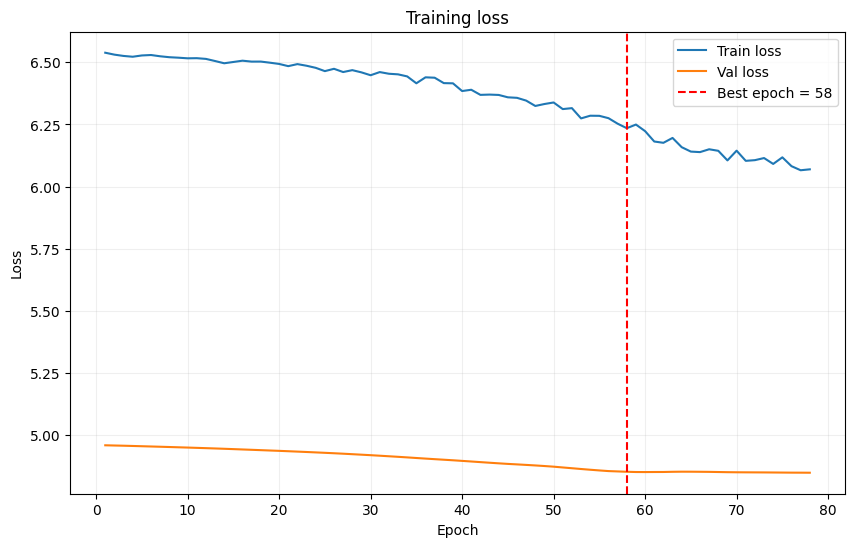

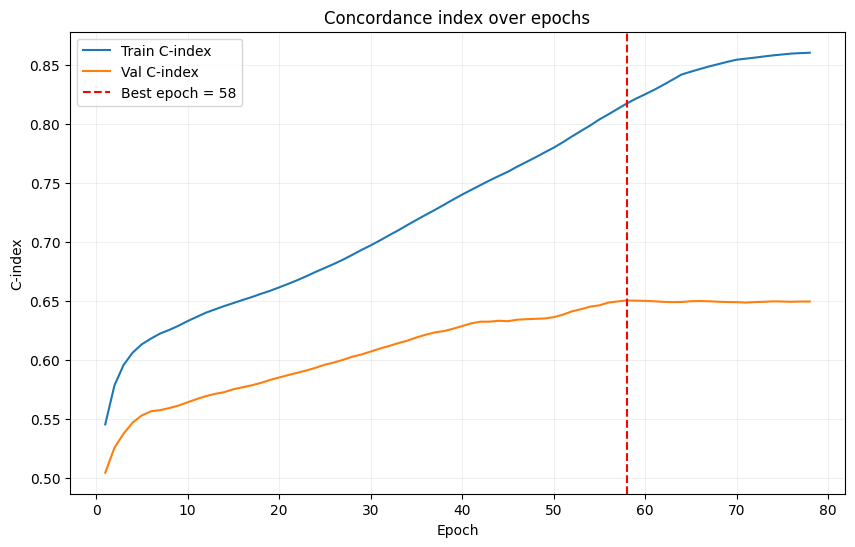

Best restored epoch: 58
Best validation loss: 4.8522


,epoch,train_loss,total_loss,gate_penalty,train_cindex,lr,val_loss,val_cindex,epoch_time_sec,elapsed_time_min
73,74,6.091271,6.091777,0.505632,0.858301,0.000075,4.849297,0.649932,0.026672,0.034060
74,75,6.117833,6.118339,0.505761,0.859059,0.000075,4.849014,0.649801,0.026731,0.034505
75,76,6.082242,6.082748,0.505805,0.859803,0.000075,4.848712,0.649570,0.027855,0.034970
76,77,6.065828,6.066334,0.505758,0.860204,0.000037,4.848582,0.649801,0.027580,0.035429
77,78,6.069543,6.070049,0.505878,0.860531,0.000037,4.848389,0.649834,0.026991,0.035879


In [24]:

# =========================
# Plot training history
# =========================
plt.figure(figsize=(10, 6))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
if "val_loss" in history_df.columns:
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Val loss")
if best_epoch is not None:
    plt.axvline(best_epoch, color="red", linestyle="--", label=f"Best epoch = {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.legend()
plt.grid(True, alpha=0.2)
plt.savefig("/content/drive/MyDrive/ECEN766final/ResidualGatedAttentionDeepSurv/plot_residual_gated_TrainingLoss.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(history_df["epoch"], history_df["train_cindex"], label="Train C-index")
if "val_cindex" in history_df.columns:
    plt.plot(history_df["epoch"], history_df["val_cindex"], label="Val C-index")
if best_epoch is not None:
    plt.axvline(best_epoch, color="red", linestyle="--", label=f"Best epoch = {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("C-index")
plt.title("Concordance index over epochs")
plt.legend()
plt.grid(True, alpha=0.2)
plt.savefig("/content/drive/MyDrive/ECEN766final/ResidualGatedAttentionDeepSurv/plot_residual_gated_Cindex_over_epochs.png", dpi=300)
plt.show()

print(f"Best restored epoch: {best_epoch}")
print(f"Best validation loss: {best_val_loss:.4f}")
history_df.tail()

In [23]:
# =========================
# Final evaluation
# =========================
train_ci = evaluate_cindex(model, train_data, scaler=scaler, device=DEVICE)
val_ci = evaluate_cindex(model, val_data, scaler=scaler, device=DEVICE)

print(f"Final Train C-index: {train_ci:.4f}")
print(f"Final Val   C-index: {val_ci:.4f}")

if test_data is not None:
    test_ci = evaluate_cindex(model, test_data, scaler=scaler, device=DEVICE)
    print(f"Final Test  C-index: {test_ci:.4f}")

Final Train C-index: 0.8175
Final Val   C-index: 0.6507
Final Test  C-index: 0.6615


Top gated genes:


,rank,gene,mean_gate_score,std_gate_score
0,1,FGF2,0.713883,0.080126
1,2,SULT1E1,0.683405,0.094236
2,3,PSAP,0.673315,0.098695
3,4,CYB561D2,0.667160,0.074271
4,5,MEFV,0.667067,0.098020
...,...,...,...,...
95,96,FDPS,0.612739,0.089907
96,97,SPINLW1,0.612094,0.115562
97,98,CXorf1,0.611836,0.099181
98,99,TRPV5,0.611784,0.100718


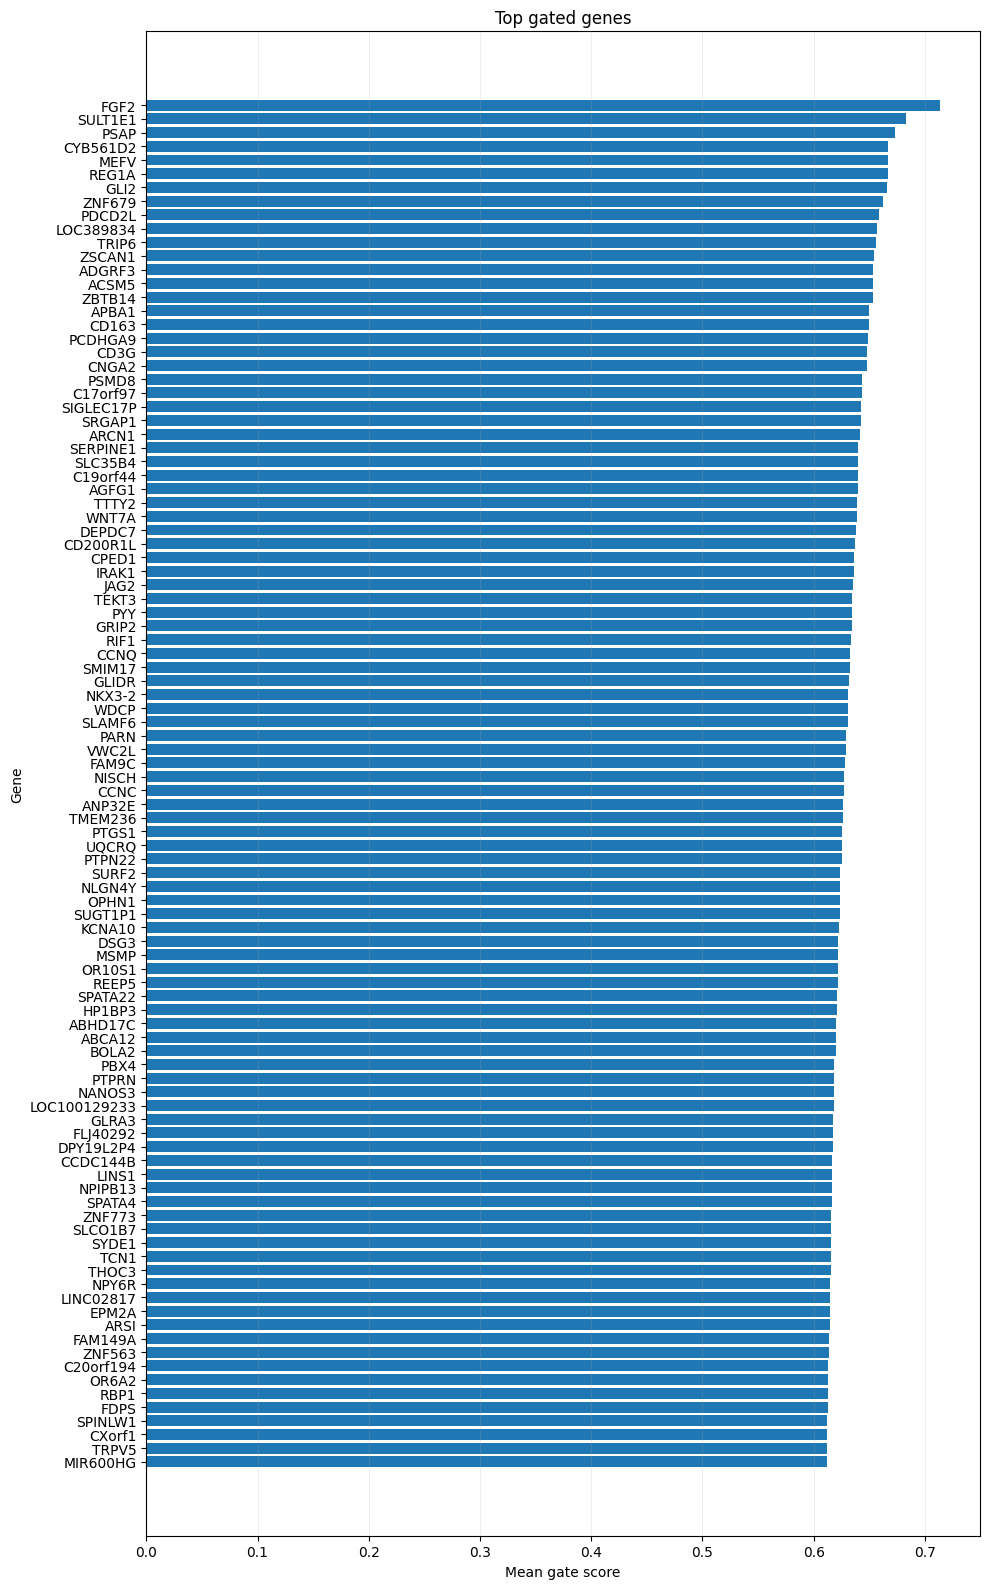

In [27]:
TOP_K = 100

# Put model in eval mode
model.eval()

# Use whichever split you want to summarize
# train_data / val_data / test_data
x_all = torch.tensor(train_data["x"], dtype=torch.float32, device=DEVICE)

# Apply scaler if used
if scaler is not None:
    x_all = scaler.transform(x_all)

# Get gates from the trained residual gated model
with torch.no_grad():
    _, gates = model(x_all, return_attention=True)

# gates shape: [n_patients, n_genes]
gates_np = gates.detach().cpu().numpy()

# Mean and std gate score across patients
mean_gate_scores = gates_np.mean(axis=0)
std_gate_scores = gates_np.std(axis=0)

# Create summary table
gate_summary_df = pd.DataFrame({
    "gene": feature_names,
    "mean_gate_score": mean_gate_scores,
    "std_gate_score": std_gate_scores,
}).sort_values("mean_gate_score", ascending=False).reset_index(drop=True)

# Top-K genes
top_genes_df = gate_summary_df.head(TOP_K).copy()
top_genes_df.insert(0, "rank", range(1, len(top_genes_df) + 1))

# Display table
print("Top gated genes:")
display(top_genes_df)

# Plot
plot_df = top_genes_df.sort_values("mean_gate_score", ascending=True)

plt.figure(figsize=(10, 16))
plt.barh(plot_df["gene"], plot_df["mean_gate_score"])
plt.xlabel("Mean gate score")
plt.ylabel("Gene")
plt.title("Top gated genes")
plt.grid(True, axis="x", alpha=0.2)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ECEN766final/ResidualGatedAttentionDeepSurv/plot_top_100genes.png", dpi=300)
plt.show()